# 🚀 ML Training Pipeline — CIC-IDS-2018
## Complete Fixed Pipeline + Correlation Feature Reduction

| Fix | Description |
|-----|-------------|
| ✅ Corrupt rows removed | Negative values from CICFlowMeter bug |
| ✅ Correct scaling order | Split → fit on train only → transform both |
| ✅ Honest metrics | Balanced Accuracy + per-class Recall |
| ✅ Correlation feature drop | 57 → 34 features (23 redundant removed) |
| ✅ No data leakage | Correlation computed before split |

**Features dropped (23):** Subflow Fwd Pkts, Fwd Seg Size Avg, Bwd Seg Size Avg, Subflow Fwd Byts, Subflow Bwd Pkts, TotLen Bwd Pkts, ECE Flag Cnt, Tot Fwd Pkts, Bwd Header Len, Idle Min, Fwd IAT Tot, Idle Mean, Subflow Bwd Byts, Pkt Len Mean, Flow IAT Min, Fwd Header Len, Fwd IAT Max, Flow IAT Mean, Fwd IAT Min, Bwd Pkt Len Std, Pkt Len Std, Fwd Pkt Len Std, Bwd Pkt Len Max

**34 surviving features** — all highly correlated duplicates removed, most predictive kept.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import time
import pickle
import warnings
import gc
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    balanced_accuracy_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

print('=' * 80)
print('🚀 ML TRAINING — CIC-IDS-2018 | FIXED PIPELINE + CORRELATION DROP')
print('=' * 80)


🚀 ML TRAINING — CIC-IDS-2018 | FIXED PIPELINE + CORRELATION DROP


## 2. Configuration

In [2]:
INPUT_FILE     = 'archive/full_df_binary_labels.csv'
BASE_MODEL_DIR = 'trained_models/ml_corr_drop/'
TEST_SIZE      = 0.2
RANDOM_STATE   = 42
SAVE_MODELS    = True

# ── Features dropped by correlation analysis (23 features) ──────────────
CORRELATION_DROP = [
    'Subflow Fwd Pkts', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg',
    'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'TotLen Bwd Pkts',
    'ECE Flag Cnt', 'Tot Fwd Pkts', 'Bwd Header Len', 'Idle Min',
    'Fwd IAT Tot', 'Idle Mean', 'Subflow Bwd Byts', 'Pkt Len Mean',
    'Flow IAT Min', 'Fwd Header Len', 'Fwd IAT Max', 'Flow IAT Mean',
    'Fwd IAT Min', 'Bwd Pkt Len Std', 'Pkt Len Std', 'Fwd Pkt Len Std',
    'Bwd Pkt Len Max'
]

# ── Physically impossible negatives ──────────────────────────────────────
NON_NEGATIVE_FEATURES = [
    'Flow Duration', 'Flow IAT Mean', 'Flow IAT Std',
    'Flow IAT Max',  'Flow IAT Min',  'Fwd IAT Tot',
    'Fwd IAT Mean',  'Fwd IAT Std',   'Fwd IAT Max',
    'Fwd IAT Min',   'Bwd IAT Tot',   'Bwd IAT Mean',
    'Bwd IAT Std',   'Bwd IAT Max',   'Bwd IAT Min',
    'Idle Mean',     'Idle Max',      'Idle Min',
    'Tot Fwd Pkts',  'Tot Bwd Pkts',  'TotLen Fwd Pkts',
    'TotLen Bwd Pkts', 'Flow Byts/s', 'Flow Pkts/s'
]

# ── Scaling groups — updated for 34 surviving features ───────────────────
# (dropped features automatically excluded)
POWER_TRANSFORMER_FEATURES = [
    'Dst Port', 'Flow Duration',
    'TotLen Fwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Mean',
    'Bwd Pkt Len Mean', 'Flow Byts/s', 'Flow Pkts/s',
    'Flow IAT Std', 'Flow IAT Max',
    'Fwd IAT Mean', 'Fwd IAT Std',
    'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
    'Fwd Pkts/s', 'Bwd Pkts/s',
    'Pkt Len Max', 'Pkt Len Var', 'Down/Up Ratio',
    'Pkt Size Avg', 'Init Fwd Win Byts', 'Init Bwd Win Byts',
    'Fwd Act Data Pkts', 'Idle Max',
    'Tot Bwd Pkts'
]
STANDARD_SCALER_FEATURES = ['Fwd Seg Size Min']
NO_SCALING_FEATURES = [
    'Protocol', 'RST Flag Cnt', 'PSH Flag Cnt',
    'ACK Flag Cnt', 'URG Flag Cnt'
]

# ── Per-model sample sizes ────────────────────────────────────────────────
MODEL_SAMPLE_SIZES = {
    'Random Forest':       None,
    'Decision Tree':       None,
    'Logistic Regression': None,
    'XGBoost':             None,
    'LightGBM':            None,
    'KNN':                 100_000,
    'Naive Bayes':         None,
    'SVM':                 50_000
}

os.makedirs(BASE_MODEL_DIR, exist_ok=True)
print('✅ Configuration set')
print(f'   Output directory : {BASE_MODEL_DIR}')
print(f'   Features dropped : {len(CORRELATION_DROP)} (correlation analysis)')
print(f'   Features kept    : 34')


✅ Configuration set
   Output directory : trained_models/ml_corr_drop/
   Features dropped : 23 (correlation analysis)
   Features kept    : 34


## 3. Load Dataset

In [3]:
CHUNK_SIZE = 100_000
chunks, total = [], 0

print(f'\n📂 Loading data from: {INPUT_FILE}')
print('⏳ Reading in chunks...\n')

for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    chunks.append(chunk)
    total += len(chunk)
    if (i + 1) % 20 == 0:
        print(f'   Chunk {i+1:>4}: {len(chunk):,} rows | Total: {total:,}')

df_full = pd.concat(chunks, ignore_index=True)
del chunks

df_full = df_full.drop(columns=['Label'], errors='ignore')

print(f'\n✅ Dataset loaded')
print(f'   Rows   : {len(df_full):,}')
print(f'   Columns: {len(df_full.columns)}')
print(f'\nRaw class distribution:')
print(df_full['Label_Binary'].value_counts())



📂 Loading data from: archive/full_df_binary_labels.csv
⏳ Reading in chunks...

   Chunk   20: 100,000 rows | Total: 2,000,000
   Chunk   40: 100,000 rows | Total: 4,000,000
   Chunk   60: 100,000 rows | Total: 6,000,000
   Chunk   80: 100,000 rows | Total: 8,000,000
   Chunk  100: 100,000 rows | Total: 10,000,000
   Chunk  120: 100,000 rows | Total: 12,000,000
   Chunk  140: 100,000 rows | Total: 14,000,000
   Chunk  160: 100,000 rows | Total: 16,000,000

✅ Dataset loaded
   Rows   : 16,232,943
   Columns: 58

Raw class distribution:
Label_Binary
0    13484708
1     2748235
Name: count, dtype: int64


## 4. Data Cleaning — Remove Corrupt Rows
CICFlowMeter has a known bug where timestamp overflows produce **negative** values in duration and inter-arrival time features. These rows are corrupted and removed.

In [4]:
print('=' * 80)
print('🧹 REMOVING CORRUPT ROWS (impossible negatives)')
print('=' * 80)

before = len(df_full)
cols_check = [c for c in NON_NEGATIVE_FEATURES if c in df_full.columns]

print('\nNegative value counts per feature:')
for col in cols_check:
    n_bad = (df_full[col] < 0).sum()
    if n_bad > 0:
        print(f'  ⚠️  {col:<35} {n_bad:>8,} corrupt values')

corrupt_mask = (df_full[cols_check] < 0).any(axis=1)
df_full      = df_full[~corrupt_mask].copy()

print(f'\n  Before : {before:>12,}')
print(f'  Removed: {before - len(df_full):>12,} corrupt rows')
print(f'  After  : {len(df_full):>12,}')


🧹 REMOVING CORRUPT ROWS (impossible negatives)

Negative value counts per feature:
  ⚠️  Flow Duration                             14 corrupt values
  ⚠️  Flow IAT Mean                             14 corrupt values
  ⚠️  Flow IAT Max                               3 corrupt values
  ⚠️  Flow IAT Min                              15 corrupt values
  ⚠️  Fwd IAT Tot                               14 corrupt values
  ⚠️  Fwd IAT Mean                              14 corrupt values
  ⚠️  Fwd IAT Max                                3 corrupt values
  ⚠️  Fwd IAT Min                               15 corrupt values
  ⚠️  Flow Pkts/s                               14 corrupt values

  Before :   16,232,943
  Removed:           15 corrupt rows
  After  :   16,232,928


## 5. Prepare Features + Apply Correlation Drop
Drop the 23 features identified as redundant by the full-dataset correlation analysis. For each correlated pair, the feature with **lower label-correlation was dropped**, keeping the more predictive one.

In [5]:
print('\n' + '=' * 80)
print('🔧 PREPARING FEATURES + APPLYING CORRELATION DROP')
print('=' * 80)

X_full = df_full.drop(['Label_Binary'], axis=1).select_dtypes(include=[np.number])
y_full = df_full['Label_Binary']
del df_full

# Step 1: Drop zero-variance features
constant_cols = [c for c in X_full.columns if X_full[c].std() < 1e-10]
if constant_cols:
    print(f'\n  Dropping {len(constant_cols)} zero-variance features:')
    for c in constant_cols:
        print(f'    - {c}')
    X_full = X_full.drop(columns=constant_cols)
else:
    print('\n  ✅ No zero-variance features found')

# Step 2: Apply correlation drop
cols_to_drop = [c for c in CORRELATION_DROP if c in X_full.columns]
X_full = X_full.drop(columns=cols_to_drop)
print(f'\n  ✅ Correlation drop applied: removed {len(cols_to_drop)} features')
print(f'     Dropped: {cols_to_drop}')

print(f'\n✅ Features shape : {X_full.shape}')
print(f'✅ Labels shape   : {y_full.shape}')
print(f'\nClass distribution:')
vc = y_full.value_counts()
for k, v in vc.items():
    label = 'Benign' if k == 0 else 'Attack'
    print(f'  {label} ({k}): {v:>10,}  ({v/len(y_full)*100:.1f}%)')

print(f'\n📋 Surviving features ({X_full.shape[1]}):')
for i, f in enumerate(X_full.columns.tolist(), 1):
    print(f'  {i:2d}. {f}')



🔧 PREPARING FEATURES + APPLYING CORRELATION DROP

  ✅ No zero-variance features found

  ✅ Correlation drop applied: removed 23 features
     Dropped: ['Subflow Fwd Pkts', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'TotLen Bwd Pkts', 'ECE Flag Cnt', 'Tot Fwd Pkts', 'Bwd Header Len', 'Idle Min', 'Fwd IAT Tot', 'Idle Mean', 'Subflow Bwd Byts', 'Pkt Len Mean', 'Flow IAT Min', 'Fwd Header Len', 'Fwd IAT Max', 'Flow IAT Mean', 'Fwd IAT Min', 'Bwd Pkt Len Std', 'Pkt Len Std', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max']

✅ Features shape : (16232928, 34)
✅ Labels shape   : (16232928,)

Class distribution:
  Benign (0): 13,484,693  (83.1%)
  Attack (1):  2,748,235  (16.9%)

📋 Surviving features (34):
   1. Dst Port
   2. Protocol
   3. Flow Duration
   4. Tot Bwd Pkts
   5. TotLen Fwd Pkts
   6. Fwd Pkt Len Max
   7. Fwd Pkt Len Mean
   8. Bwd Pkt Len Mean
   9. Flow Byts/s
  10. Flow Pkts/s
  11. Flow IAT Std
  12. Flow IAT Max
  13. Fwd IAT Mean
  14. Fwd IAT 

## 6. Helper Function — Prepare Data Per Model

In [6]:
def get_model_data(X_full, y_full, model_name, sample_size=None,
                   test_size=0.2, random_state=42):
    """
    Prepare train/test data for a model.
    CORRECT ORDER:
      1. Sample (optional, for slow models)
      2. Split train/test FIRST
      3. Fit scalers on TRAIN only
      4. Transform both sets with fitted scalers
    No data leakage possible with this order.
    """
    X = X_full.copy()
    y = y_full.copy()

    # Optional sampling
    if sample_size is not None and sample_size < len(X):
        print(f'   📊 Sampling {sample_size:,} rows (from {len(X):,})')
        X, _, y, _ = train_test_split(
            X, y, train_size=sample_size,
            random_state=random_state, stratify=y
        )
        print(f'   Sampled class dist: {y.value_counts().to_dict()}')
    else:
        print(f'   📊 Using full dataset: {len(X):,} rows')

    # STEP 1: Split FIRST — test set isolated immediately
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    print(f'   Train: {len(X_train):,} rows | Test: {len(X_test):,} rows')

    X_train = X_train.copy()
    X_test  = X_test.copy()

    # STEP 2: Fit scalers on TRAIN only, transform both
    print('   🔧 Scaling (fit on train only — no leakage)...')
    scalers = {}

    # PowerTransformer — for features present in X_train after correlation drop
    power_cols = [
        c for c in POWER_TRANSFORMER_FEATURES
        if c in X_train.columns and X_train[c].std() > 1e-10
    ]
    if power_cols:
        pt = PowerTransformer(method='yeo-johnson', standardize=True)
        pt.fit(X_train[power_cols])
        X_train[power_cols] = pt.transform(X_train[power_cols])
        X_test[power_cols]  = pt.transform(X_test[power_cols])
        scalers['power'] = pt
        print(f'      PowerTransformer : {len(power_cols)} features')

    # StandardScaler
    std_cols = [
        c for c in STANDARD_SCALER_FEATURES
        if c in X_train.columns and X_train[c].std() > 1e-10
    ]
    if std_cols:
        ss = StandardScaler()
        ss.fit(X_train[std_cols])
        X_train[std_cols] = ss.transform(X_train[std_cols])
        X_test[std_cols]  = ss.transform(X_test[std_cols])
        scalers['standard'] = ss
        print(f'      StandardScaler   : {len(std_cols)} features')

    no_scale = [c for c in NO_SCALING_FEATURES if c in X_train.columns]
    if no_scale:
        print(f'      Unscaled         : {len(no_scale)} binary/flag features')

    print('   ✅ Scaling complete')
    return X_train, X_test, y_train, y_test, scalers

print('✅ Helper function defined')


✅ Helper function defined


## 7. Define Models

In [7]:
model_builders = {
    'Random Forest': lambda: RandomForestClassifier(
        n_estimators=100, max_depth=20, min_samples_split=10,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    'Decision Tree': lambda: DecisionTreeClassifier(
        max_depth=20, min_samples_split=10, random_state=RANDOM_STATE
    ),
    'Logistic Regression': lambda: LogisticRegression(
        max_iter=1000, n_jobs=-1, random_state=RANDOM_STATE
    ),
    'XGBoost': lambda: XGBClassifier(
        n_estimators=100, max_depth=10, learning_rate=0.1,
        n_jobs=-1, random_state=RANDOM_STATE, eval_metric='logloss'
    ),
    'LightGBM': lambda: LGBMClassifier(
        n_estimators=100, max_depth=10, learning_rate=0.1,
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
    ),
    'KNN': lambda: KNeighborsClassifier(
        n_neighbors=5, n_jobs=-1
    ),
    'Naive Bayes': lambda: GaussianNB(),
    'SVM': lambda: SVC(
        kernel='rbf', C=1.0, random_state=RANDOM_STATE
    )
}

print(f'✅ Defined {len(model_builders)} models to train:')
for name in model_builders:
    sample = MODEL_SAMPLE_SIZES.get(name)
    sample_str = f'{sample:,} rows' if sample else 'full dataset'
    print(f'   - {name:<25} ({sample_str})')


✅ Defined 8 models to train:
   - Random Forest             (full dataset)
   - Decision Tree             (full dataset)
   - Logistic Regression       (full dataset)
   - XGBoost                   (full dataset)
   - LightGBM                  (full dataset)
   - KNN                       (100,000 rows)
   - Naive Bayes               (full dataset)
   - SVM                       (50,000 rows)


## 8. Train All Models

In [8]:
results        = {}
trained_models = {}
saved_scalers  = {}

for model_name, model_builder in model_builders.items():
    print('\n' + '=' * 80)
    print(f'🚀 TRAINING: {model_name}')
    print('=' * 80)

    model_dir = os.path.join(BASE_MODEL_DIR, model_name.lower().replace(' ', '_'))
    os.makedirs(model_dir, exist_ok=True)
    print(f'📁 Model directory: {model_dir}')

    sample_size = MODEL_SAMPLE_SIZES.get(model_name, None)

    # Prepare data
    X_train, X_test, y_train, y_test, scalers = get_model_data(
        X_full, y_full, model_name, sample_size, TEST_SIZE, RANDOM_STATE
    )
    saved_scalers[model_name] = scalers

    # Train
    model = model_builder()
    print(f'\n⏱️  Training...')
    start      = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    print(f'✅ Training completed in {train_time:.2f}s ({train_time/60:.2f} min)')

    # Predict
    print(f'\n🔮 Making predictions...')
    start     = time.time()
    y_pred    = model.predict(X_test)
    pred_time = time.time() - start
    print(f'✅ Predictions completed in {pred_time:.2f}s')

    # Metrics
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='binary', zero_division=0)
    f1        = f1_score(y_test, y_pred, average='binary', zero_division=0)
    f1_mac    = f1_score(y_test, y_pred, average='macro', zero_division=0)
    bal_acc   = balanced_accuracy_score(y_test, y_pred)
    cm        = confusion_matrix(y_test, y_pred)

    # Per-class recall & precision from confusion matrix
    tn, fp, fn, tp = cm.ravel()
    benign_recall    = tn / (tn + fp) if (tn + fp) > 0 else 0
    attack_recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    benign_precision = tn / (tn + fn) if (tn + fn) > 0 else 0
    attack_precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    print(f'\n📊 RESULTS:')
    print(f'   Accuracy         : {accuracy:.4f}')
    print(f'   Balanced Accuracy: {bal_acc:.4f}  ← primary metric')
    print(f'   Precision        : {precision:.4f}')
    print(f'   Recall (Attack)  : {recall:.4f}')
    print(f'   F1-Score (binary): {f1:.4f}')
    print(f'   F1-Score (macro) : {f1_mac:.4f}')
    print(f'   Benign Recall    : {benign_recall:.4f}')
    print(f'   Attack Recall    : {attack_recall:.4f}')

    print(f'\n🕐 TIME:')
    print(f'   Train: {train_time:.2f}s ({train_time/60:.2f} min)')
    print(f'   Test : {pred_time:.2f}s')

    print(f'\n🎯 Confusion Matrix:')
    print(cm)
    print(f'   TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')

    print(f'\n📋 Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['Benign','Attack'], zero_division=0))

    results[model_name] = {
        'accuracy'         : accuracy,
        'balanced_accuracy': bal_acc,
        'precision'        : precision,
        'recall'           : recall,
        'f1_score'         : f1,
        'f1_macro'         : f1_mac,
        'benign_recall'    : benign_recall,
        'attack_recall'    : attack_recall,
        'benign_precision' : benign_precision,
        'attack_precision' : attack_precision,
        'train_time'       : train_time,
        'pred_time'        : pred_time,
        'confusion_matrix' : cm,
        'predictions'      : y_pred,
        'sample_size'      : len(X_train) + len(X_test),
        'train_samples'    : len(X_train),
        'test_samples'     : len(X_test),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }
    trained_models[model_name] = model

    # Save
    if SAVE_MODELS:
        with open(os.path.join(model_dir, 'model.pkl'), 'wb') as f:
            pickle.dump(model, f)
        with open(os.path.join(model_dir, 'scalers.pkl'), 'wb') as f:
            pickle.dump(scalers, f)
        metadata = {
            'model_name'    : model_name,
            'n_features'    : X_train.shape[1],
            'feature_names' : X_train.columns.tolist(),
            'sample_size'   : sample_size,
            'train_samples' : len(X_train),
            'test_samples'  : len(X_test),
            'train_time'    : train_time,
            'correlation_dropped': CORRELATION_DROP,
            'metrics'       : {
                'accuracy'         : accuracy,
                'balanced_accuracy': bal_acc,
                'precision'        : precision,
                'recall'           : recall,
                'f1_score'         : f1,
                'f1_macro'         : f1_mac,
                'benign_recall'    : benign_recall,
                'attack_recall'    : attack_recall
            }
        }
        with open(os.path.join(model_dir, 'metadata.pkl'), 'wb') as f:
            pickle.dump(metadata, f)
        print(f'💾 Saved → {model_dir}/')
    del X_train, X_test, y_train, y_test, scalers, y_pred
    gc.collect()    

print('\n' + '=' * 80)
print('✅ ALL MODELS TRAINED & TESTED!')
print('=' * 80)



🚀 TRAINING: Random Forest
📁 Model directory: trained_models/ml_corr_drop/random_forest
   📊 Using full dataset: 16,232,928 rows
   Train: 12,986,342 rows | Test: 3,246,586 rows
   🔧 Scaling (fit on train only — no leakage)...
      PowerTransformer : 28 features
      StandardScaler   : 1 features
      Unscaled         : 5 binary/flag features
   ✅ Scaling complete

⏱️  Training...
✅ Training completed in 784.29s (13.07 min)

🔮 Making predictions...
✅ Predictions completed in 5.31s

📊 RESULTS:
   Accuracy         : 0.9901
   Balanced Accuracy: 0.9717  ← primary metric
   Precision        : 0.9975
   Recall (Attack)  : 0.9439
   F1-Score (binary): 0.9700
   F1-Score (macro) : 0.9820
   Benign Recall    : 0.9995
   Attack Recall    : 0.9439

🕐 TIME:
   Train: 784.29s (13.07 min)
   Test : 5.31s

🎯 Confusion Matrix:
[[2695656    1283]
 [  30823  518824]]
   TN=2,695,656  FP=1,283  FN=30,823  TP=518,824

📋 Classification Report:
              precision    recall  f1-score   support

    

## 9. Results Summary

In [9]:
summary_df = pd.DataFrame(results).T
summary_df = summary_df[[
    'balanced_accuracy', 'f1_macro', 'benign_recall', 'attack_recall',
    'benign_precision', 'attack_precision', 'accuracy', 'train_time', 'sample_size'
]].astype({
    'balanced_accuracy': float, 'f1_macro': float,
    'benign_recall': float, 'attack_recall': float,
    'benign_precision': float, 'attack_precision': float,
    'accuracy': float, 'train_time': float, 'sample_size': int
})
summary_df = summary_df.sort_values('balanced_accuracy', ascending=False)

print('\n' + '=' * 80)
print('📊 FINAL RESULTS — HONEST METRICS (34 features after correlation drop)')
print('=' * 80)
print('\nRanked by Balanced Accuracy (primary metric):')
print(summary_df.to_string())

print('\n⚠️  NOTE: Plain accuracy is NOT the primary metric — it is misleading on imbalanced data.')
print('    Balanced Accuracy = average of Benign Recall and Attack Recall')
print('    A good IDS needs HIGH recall on BOTH classes:')
print('    Low Benign Recall  → too many false alarms (legitimate traffic flagged)')
print('    Low Attack Recall  → attacks are slipping through undetected')

summary_df.to_csv(f'{BASE_MODEL_DIR}results_summary.csv')
print(f'\n✅ Results saved → {BASE_MODEL_DIR}results_summary.csv')
summary_df



📊 FINAL RESULTS — HONEST METRICS (34 features after correlation drop)

Ranked by Balanced Accuracy (primary metric):
                     balanced_accuracy  f1_macro  benign_recall  attack_recall  benign_precision  attack_precision  accuracy  train_time  sample_size
Decision Tree                 0.972041  0.981751       0.999107       0.944976          0.988900          0.995383  0.989942  340.938167     16232928
Random Forest                 0.971723  0.982034       0.999524       0.943922          0.988695          0.997533  0.990111  784.287315     16232928
XGBoost                       0.971539  0.982046       0.999636       0.943442          0.988600          0.998108  0.990122   44.005142     16232928
KNN                           0.971273  0.979731       0.997773       0.944773          0.988845          0.988566  0.988800    0.015691       100000
LightGBM                      0.970776  0.981740       0.999787       0.941764          0.988268          0.998890  0.989964   32.24

,balanced_accuracy,f1_macro,benign_recall,attack_recall,benign_precision,attack_precision,accuracy,train_time,sample_size
Decision Tree,0.972041,0.981751,0.999107,0.944976,0.988900,0.995383,0.989942,340.938167,16232928
Random Forest,0.971723,0.982034,0.999524,0.943922,0.988695,0.997533,0.990111,784.287315,16232928
XGBoost,0.971539,0.982046,0.999636,0.943442,0.988600,0.998108,0.990122,44.005142,16232928
KNN,0.971273,0.979731,0.997773,0.944773,0.988845,0.988566,0.988800,0.015691,100000
LightGBM,0.970776,0.981740,0.999787,0.941764,0.988268,0.998890,0.989964,32.241983,16232928
SVM,0.931607,0.950102,0.994342,0.868872,0.973827,0.969038,0.973100,6.338972,50000
Logistic Regression,0.922010,0.932501,0.983921,0.860099,0.971838,0.915980,0.962958,374.037716,16232928
Naive Bayes,0.719766,0.650691,0.751517,0.688014,0.921993,0.360738,0.740766,6.861738,16232928


## 10. Visualisations — Model Performance


📊 Creating visualisations...
✅ Saved → trained_models/ml_corr_drop/model_comparison.png


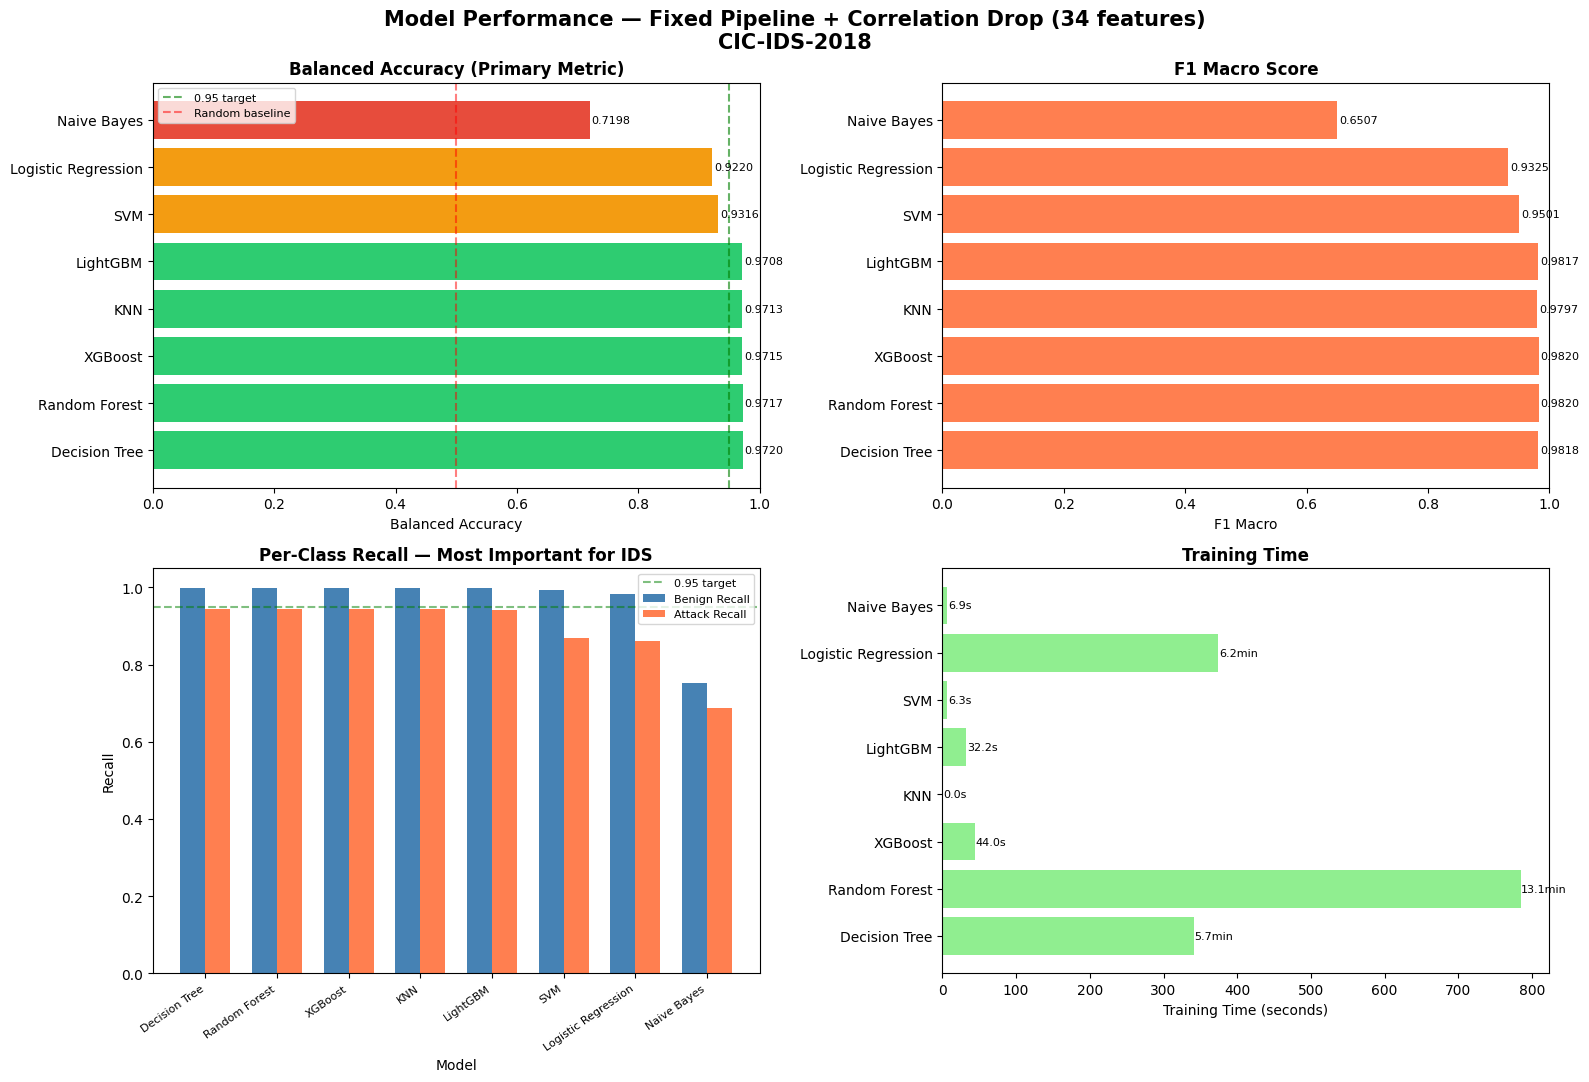

In [10]:
print('\n📊 Creating visualisations...')

model_names = summary_df.index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    'Model Performance — Fixed Pipeline + Correlation Drop (34 features)\nCIC-IDS-2018',
    fontsize=15, fontweight='bold'
)

# ── Balanced Accuracy ──
colors_ba = ['#2ecc71' if v >= 0.95 else '#f39c12' if v >= 0.90 else '#e74c3c'
             for v in summary_df['balanced_accuracy']]
axes[0,0].barh(model_names, summary_df['balanced_accuracy'], color=colors_ba)
axes[0,0].set_xlabel('Balanced Accuracy')
axes[0,0].set_title('Balanced Accuracy (Primary Metric)', fontweight='bold')
axes[0,0].set_xlim(0, 1)
axes[0,0].axvline(0.95, color='green',  linestyle='--', alpha=0.6, label='0.95 target')
axes[0,0].axvline(0.5,  color='red',    linestyle='--', alpha=0.5, label='Random baseline')
for i, v in enumerate(summary_df['balanced_accuracy']):
    axes[0,0].text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=8)
axes[0,0].legend(fontsize=8)

# ── F1 Macro ──
axes[0,1].barh(model_names, summary_df['f1_macro'], color='coral')
axes[0,1].set_xlabel('F1 Macro')
axes[0,1].set_title('F1 Macro Score', fontweight='bold')
axes[0,1].set_xlim(0, 1)
for i, v in enumerate(summary_df['f1_macro']):
    axes[0,1].text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=8)

# ── Per-class Recall ──
x     = np.arange(len(model_names))
width = 0.35
axes[1,0].bar(x - width/2, summary_df['benign_recall'], width,
              label='Benign Recall', color='steelblue')
axes[1,0].bar(x + width/2, summary_df['attack_recall'], width,
              label='Attack Recall', color='coral')
axes[1,0].set_xlabel('Model')
axes[1,0].set_ylabel('Recall')
axes[1,0].set_title('Per-Class Recall — Most Important for IDS', fontweight='bold')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(model_names, rotation=35, ha='right', fontsize=8)
axes[1,0].set_ylim(0, 1.05)
axes[1,0].axhline(0.95, color='green', linestyle='--', alpha=0.5, label='0.95 target')
axes[1,0].legend(fontsize=8)

# ── Training Time ──
axes[1,1].barh(model_names, summary_df['train_time'], color='lightgreen')
axes[1,1].set_xlabel('Training Time (seconds)')
axes[1,1].set_title('Training Time', fontweight='bold')
for i, v in enumerate(summary_df['train_time']):
    label = f'{v:.1f}s' if v < 60 else f'{v/60:.1f}min'
    axes[1,1].text(v + 1, i, label, va='center', fontsize=8)

plt.tight_layout()
plot_path = os.path.join(BASE_MODEL_DIR, 'model_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {plot_path}')
plt.show()


## 11. Confusion Matrices

✅ Saved → trained_models/ml_corr_drop/confusion_matrices.png


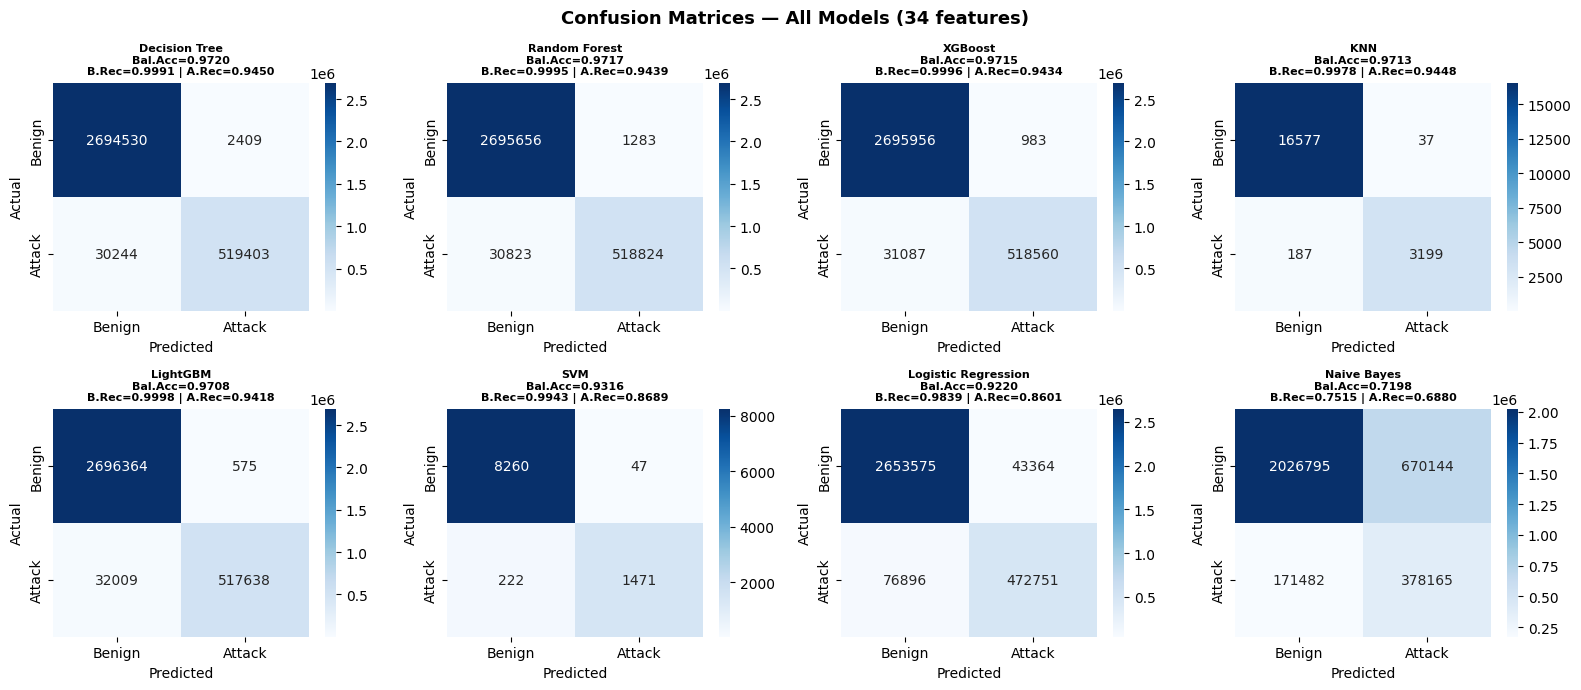

In [11]:
n_models = len(trained_models)
ncols    = 4
nrows    = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for idx, model_name in enumerate(summary_df.index):  # ordered by balanced accuracy
    r   = results[model_name]
    cm  = r['confusion_matrix']
    bal = r['balanced_accuracy']
    br  = r['benign_recall']
    ar  = r['attack_recall']

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Benign', 'Attack'],
                yticklabels=['Benign', 'Attack'])
    axes[idx].set_title(
        f'{model_name}\nBal.Acc={bal:.4f}\nB.Rec={br:.4f} | A.Rec={ar:.4f}',
        fontweight='bold', fontsize=8
    )
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

for idx in range(len(trained_models), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Confusion Matrices — All Models (34 features)', fontsize=13, fontweight='bold')
plt.tight_layout()
cm_path = os.path.join(BASE_MODEL_DIR, 'confusion_matrices.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {cm_path}')
plt.show()


## 12. Detailed Metrics Heatmap

✅ Saved → trained_models/ml_corr_drop/metrics_heatmap.png


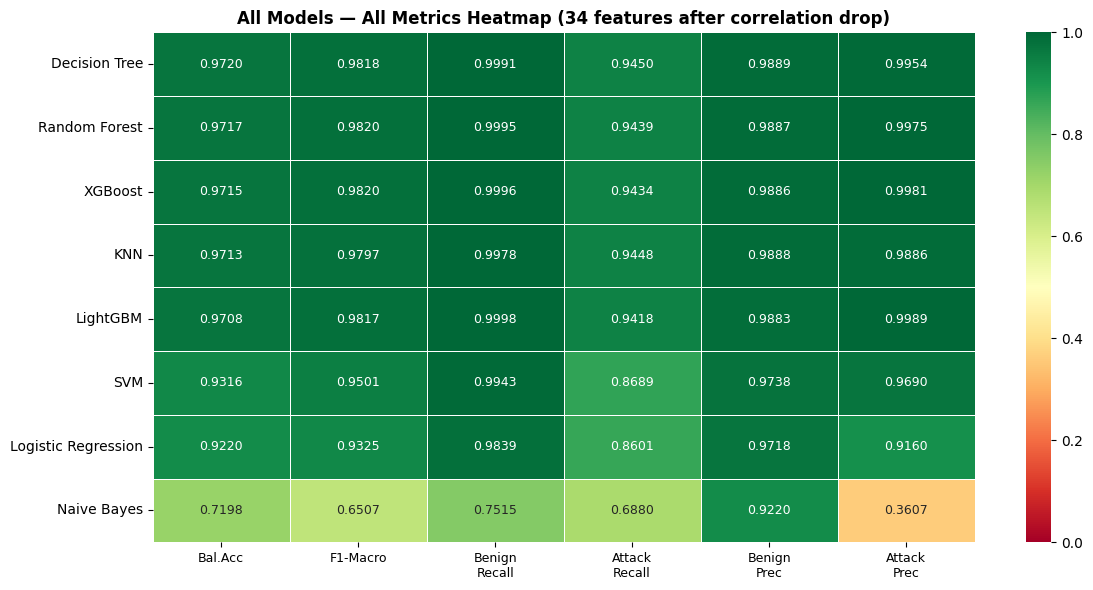

In [12]:
metric_cols = ['balanced_accuracy', 'f1_macro', 'benign_recall', 'attack_recall',
               'benign_precision', 'attack_precision']
metric_df = summary_df[metric_cols].astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    metric_df, annot=True, fmt='.4f',
    cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title(
    'All Models — All Metrics Heatmap (34 features after correlation drop)',
    fontsize=12, fontweight='bold'
)
ax.set_xticklabels(
    ['Bal.Acc', 'F1-Macro', 'Benign\nRecall', 'Attack\nRecall',
     'Benign\nPrec', 'Attack\nPrec'],
    rotation=0, fontsize=9
)
plt.tight_layout()
heat_path = os.path.join(BASE_MODEL_DIR, 'metrics_heatmap.png')
plt.savefig(heat_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {heat_path}')
plt.show()


## 13. Final Summary

In [14]:
print('\n' + '=' * 80)
print('🎉 TRAINING COMPLETE — FIXED PIPELINE + CORRELATION DROP')
print('=' * 80)

print('\n📋 What was applied in this notebook:')
print('   ✅ Corrupt rows removed         (impossible negative values from CICFlowMeter bug)')
print('   ✅ Scaling done correctly        (split first → fit on train only — no leakage)')
print('   ✅ Honest metrics used           (Balanced Accuracy + per-class Recall)')
print('   ✅ Correlation feature drop      (57 → 34 features, 23 redundant removed)')
print('   ✅ Feature selection principled  (kept higher label-corr of each redundant pair)')

print('\n📊 Models Ranked by Balanced Accuracy:')
print(f'   {"Rank":<4} {"Model":<25} {"Bal.Acc":>8} {"B.Recall":>9} {"A.Recall":>9} {"F1-Mac":>7} {"Time":>8}')
print('   ' + '─' * 68)
for rank, (model_name, row) in enumerate(
        summary_df.iterrows(), 1):
    t = row['train_time']
    t_str = f'{t:.1f}s' if t < 60 else f'{t/60:.1f}m'
    print(f'   {rank:<4} {model_name:<25} '
          f'{row["balanced_accuracy"]:>8.4f} '
          f'{row["benign_recall"]:>9.4f} '
          f'{row["attack_recall"]:>9.4f} '
          f'{row["f1_macro"]:>7.4f} '
          f'{t_str:>8}')

best = summary_df.index[0]
print(f'\n🏆 Best model: {best}')
print(f'   Balanced Accuracy : {summary_df.loc[best, "balanced_accuracy"]:.4f}')
print(f'   Benign Recall     : {summary_df.loc[best, "benign_recall"]:.4f}')
print(f'   Attack Recall     : {summary_df.loc[best, "attack_recall"]:.4f}')

print(f'\n📁 All models saved to: {BASE_MODEL_DIR}')




🎉 TRAINING COMPLETE — FIXED PIPELINE + CORRELATION DROP

📋 What was applied in this notebook:
   ✅ Corrupt rows removed         (impossible negative values from CICFlowMeter bug)
   ✅ Scaling done correctly        (split first → fit on train only — no leakage)
   ✅ Honest metrics used           (Balanced Accuracy + per-class Recall)
   ✅ Correlation feature drop      (57 → 34 features, 23 redundant removed)
   ✅ Feature selection principled  (kept higher label-corr of each redundant pair)

📊 Models Ranked by Balanced Accuracy:
   Rank Model                      Bal.Acc  B.Recall  A.Recall  F1-Mac     Time
   ────────────────────────────────────────────────────────────────────
   1    Decision Tree               0.9720    0.9991    0.9450  0.9818     5.7m
   2    Random Forest               0.9717    0.9995    0.9439  0.9820    13.1m
   3    XGBoost                     0.9715    0.9996    0.9434  0.9820    44.0s
   4    KNN                         0.9713    0.9978    0.9448  0.9797    